## Eye Drowsiness Detection Model

This notebook contains the training and evaluation code for the **eye state detection model**.

**Contributor:** PRASHANT BANSAL  
**Role:** Model design, training, and evaluation  

This model is later integrated into the full Driver Drowsiness Detection system using OpenCV.

In [1]:

!pip install tensorflow numpy opencv-python scikit-learn matplotlib
!pip install kaggle

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nipungarg1409","key":"fe675e10b2f386c6b37b64dd9778c0bd"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle

!kaggle datasets download -d imadeddinedjerarda/mrl-eye-dataset
!unzip mrl-eye-dataset.zip -d mrl-eye-dataset

Streaming output truncated to the last 5000 lines.
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05431_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05432_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05433_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05434_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05435_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05436_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05437_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05438_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05439_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05440_1_1_1_0_0_01.png  
  inflating: mrl-eye-dataset/mrleyedataset/Open-Eyes/s0036_05441_1_1_1_0_0_01.png  
  inflating: mrl-eye-data

In [5]:
IMG_SIZE = 24

def load_images_from_folder(folder):
    images = []
    labels = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".png"):
                try:
                    label = int(file.split('_')[4])  # 0 = closed, 1 = open
                    path = os.path.join(root, file)
                    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    images.append(img)
                    labels.append(label)
                except:
                    pass
    return np.array(images), np.array(labels)

# Load dataset
dataset_path = "/content/mrl-eye-dataset/mrleyedataset"  # Change if different
X, y = load_images_from_folder(dataset_path)

print(f"Loaded: {len(X)} images")

Loaded: 84898 images


In [6]:
X = X / 255.0  # Normalize
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # Add channel dimension

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 59428, Test: 25470


In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,145 (586.50 KB)

 Trainable params: 150,145 (586.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9101 - loss: 0.2320 - val_accuracy: 0.9424 - val_loss: 0.1457
Epoch 2/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9598 - loss: 0.1117 - val_accuracy: 0.9699 - val_loss: 0.0849
Epoch 3/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9689 - loss: 0.0861 - val_accuracy: 0.9765 - val_loss: 0.0650
Epoch 4/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.0730 - val_accuracy: 0.9795 - val_loss: 0.0550
Epoch 5/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9765 - loss: 0.0655 - val_accuracy: 0.9804 - val_loss: 0.0547
Epoch 6/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9786 - loss: 0.0574 - val_accuracy: 0.9827 - val_loss: 0.0472
Epoch 7/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9803 - loss: 0.0546 - val_accuracy: 0.9815 - val_loss: 0.0492
Epoch 8/10
929/929 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9823 - loss: 0.0505 - val_accuracy: 

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


796/796 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9854 - loss: 0.0407
Test Accuracy: 98.54%
796/796 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     12675
           1       0.99      0.98      0.99     12795

    accuracy                           0.99     25470
   macro avg       0.99      0.99      0.99     25470
weighted avg       0.99      0.99      0.99     25470

Confusion Matrix:
 [[12512   163]
 [  209 12586]]


In [10]:
model.save("eye_state_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

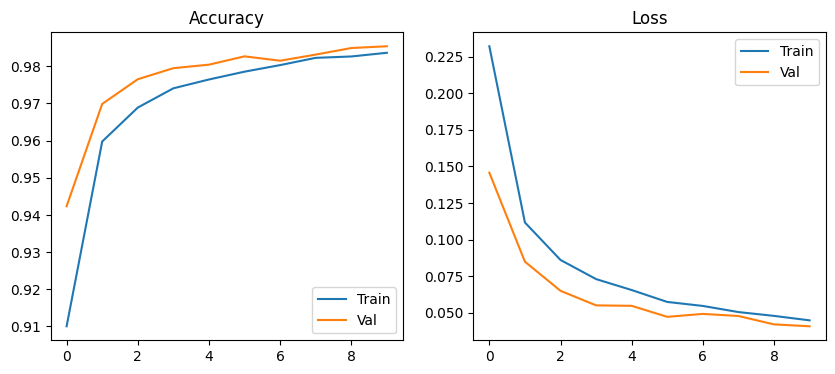

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()
